<a href="https://colab.research.google.com/github/NooraZhang/IBD-diet-and-inflammation-analysis/blob/main/IBDMDB_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dietary Intake and Inflammatory Activity in IBD

## Research Question
Is dietary intake associated with intestinal inflammation severity, as measured by fecal calprotectin?

## Data Source
The metadata were obtained from the Inflammatory Bowel Disease Multi-omics Database (IBDMDB). Each participant was followed longitudinally, so one participant may contribute observations from multiple visits.

#Import the file


In [29]:
import pandas as pd

DATA_URL = (
    "https://g-227ca.190ebd.75bc.data.globus.org/"
    "ibdmdb/metadata/hmp2_metadata_2018-08-20.csv"
)

df_raw = pd.read_csv(DATA_URL, low_memory=False)

print("Raw dataset shape:", df_raw.shape)
assert df_raw.shape == (5533, 490), \
    f"Unexpected dataset shape: {df_raw.shape}"

Raw dataset shape: (5533, 490)


In [30]:
df = df_raw.copy()
print(df.shape)

(5533, 490)


# Eliminate the unuseful variables

In [31]:
import pandas as pd
df = df_raw.copy()

columns_to_keep = [
    'Participant ID', 'week_num', 'diagnosis', 'sex', 'race', 'BMI',
    'Age at diagnosis', 'Antibiotics',
    'Immunosuppressants (e.g. oral corticosteroids)',
    'fecalcal_ng_ml', 'fecalcal', 'is_inflamed', 'hbi', 'sccai',
    'CRP (mg/L)',
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df = df[columns_to_keep]
print(df.shape)
print(df.head())

(5533, 31)
  Participant ID  week_num diagnosis     sex   race  BMI  Age at diagnosis  \
0          C3001       2.0        CD  Female  White  NaN              28.0   
1          C3001       2.0        CD  Female  White  NaN              28.0   
2          C3002       0.0        CD  Female  White  NaN              47.0   
3          C3002       0.0        CD  Female  White  NaN              47.0   
4          C3002       0.0        CD  Female  White  NaN              47.0   

  Antibiotics Immunosuppressants (e.g. oral corticosteroids)  fecalcal_ng_ml  \
0          No                                             No             NaN   
1          No                                             No             NaN   
2          No                                             No             NaN   
3          No                                             No             NaN   
4          No                                             No             NaN   

   ...  \
0  ...   
1  ...   
2  ...   

# Filter out the samples with no data of fecal calprotectin


In [32]:
inflammation_vars = ['fecalcal', 'fecalcal_ng_ml', 'is_inflamed', 'hbi', 'sccai', 'CRP (mg/L)']

for var in inflammation_vars:
    total = len(df)
    missing = df[var].isna().sum()
    valid = total - missing
    pct_missing = missing/total*100
    print(f"{var}: {valid} valid ({pct_missing:.1f}% missing)")

fecalcal: 1883 valid (66.0% missing)
fecalcal_ng_ml: 121 valid (97.8% missing)
is_inflamed: 881 valid (84.1% missing)
hbi: 2145 valid (61.2% missing)
sccai: 1335 valid (75.9% missing)
CRP (mg/L): 669 valid (87.9% missing)


In [33]:
# 重新从原始df开始，用fecalcal过滤
df_clean2 = df[df['fecalcal'].notna()]
print(df_clean2.shape)
print(df_clean2['diagnosis'].value_counts())
print(df_clean2['fecalcal'].head(10))

(1883, 31)
diagnosis
CD        928
UC        512
nonIBD    443
Name: count, dtype: int64
522    193.89000
523     61.34000
524    115.27000
525     23.20350
526     37.17836
527     48.90000
528    179.22000
529     54.33000
530     15.97901
531     14.51068
Name: fecalcal, dtype: float64


# Print the number of missing data for each variable

In [34]:
# 用fecalcal过滤
df_clean = df[df['fecalcal'].notna()].copy()

# 检查missing values
print(df_clean.isnull().sum())

Participant ID                                                                         0
week_num                                                                               0
diagnosis                                                                              0
sex                                                                                    0
race                                                                                   0
BMI                                                                                 1883
Age at diagnosis                                                                     458
Antibiotics                                                                            0
Immunosuppressants (e.g. oral corticosteroids)                                         0
fecalcal_ng_ml                                                                      1883
fecalcal                                                                               0
is_inflamed          

# Delete the variables with no data


In [35]:
# 删掉全部缺失的列
df_clean = df_clean.drop(columns=['BMI', 'fecalcal_ng_ml', 'is_inflamed', 'CRP (mg/L)'])

# 删掉饮食变量有缺失的行
dietary_cols = [
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df_clean = df_clean.dropna(subset=dietary_cols)
print(df_clean.shape)
print(df_clean['diagnosis'].value_counts())

(1739, 27)
diagnosis
CD        858
UC        468
nonIBD    413
Name: count, dtype: int64


# Visualization of the distribution of fecalcal

count    1739.000000
mean      116.573963
std       115.177453
min         3.450000
25%        16.733720
50%        54.740000
75%       212.670000
max       493.700000
Name: fecalcal, dtype: float64


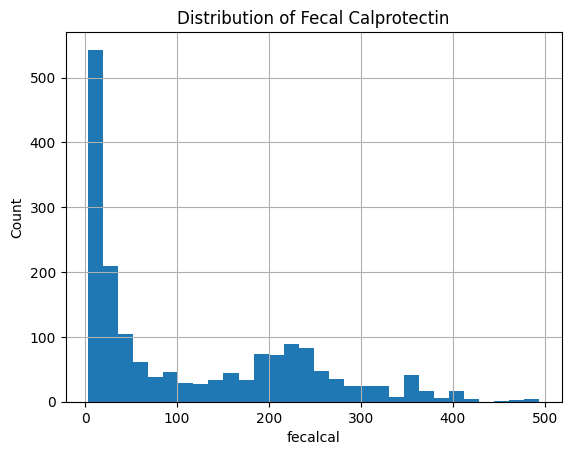

In [36]:
# 检查fecalcal的分布和outliers
print(df_clean['fecalcal'].describe())

import matplotlib.pyplot as plt
df_clean['fecalcal'].hist(bins=30)
plt.title('Distribution of Fecal Calprotectin')
plt.xlabel('fecalcal')
plt.ylabel('Count')
plt.show()

# Log-transformed visualization of the distribution of fecalcal

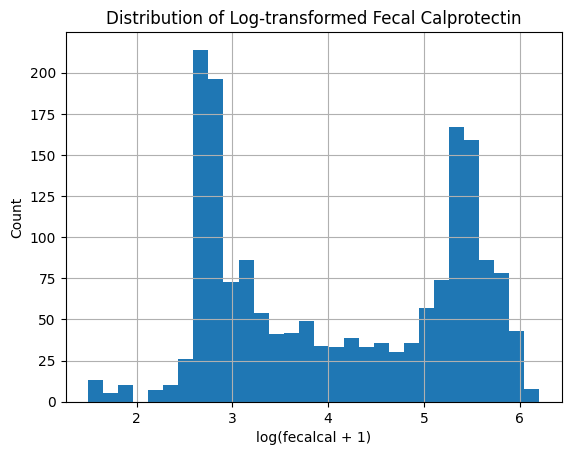

In [37]:
import numpy as np

# Log transformation
df_clean['fecalcal_log'] = np.log(df_clean['fecalcal'] + 1)

# 看看transformation之后的分布
df_clean['fecalcal_log'].hist(bins=30)
plt.title('Distribution of Log-transformed Fecal Calprotectin')
plt.xlabel('log(fecalcal + 1)')
plt.ylabel('Count')
plt.show()

#visualization of the level of inflammation of IBD and non-IBD participants

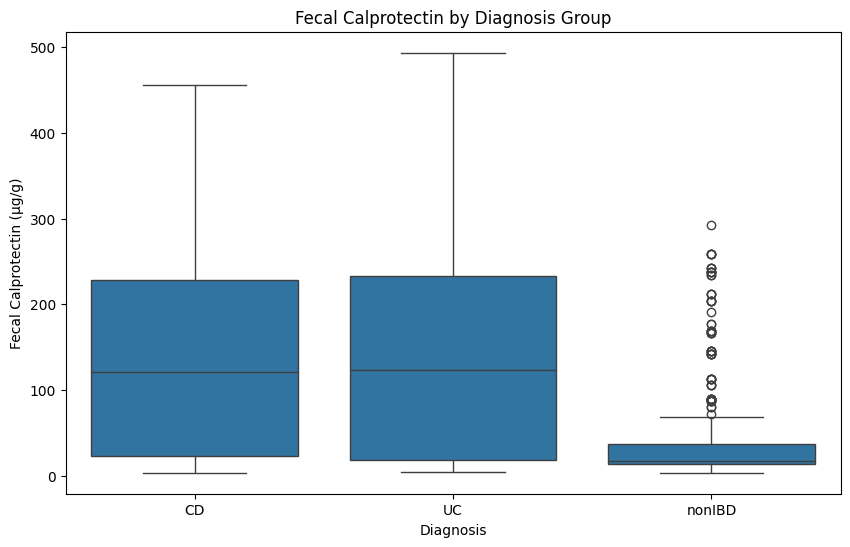

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="diagnosis",
    y="fecalcal",
    data=df_clean
)

plt.title("Fecal Calprotectin by Diagnosis Group")
plt.xlabel("Diagnosis")
plt.ylabel("Fecal Calprotectin (μg/g)")
plt.show()

#Result of the Spearman statistical test

---



In [39]:
from scipy.stats import spearmanr
import pandas as pd

dietary_cols = [
    'Red meat (beef, hamburger, pork, lamb)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Water',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'White meat (chicken, turkey, etc.)',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

frequency_map = {
    'No, I did not consume these products in the last 7 days': 0,
    'Within the past 4 to 7 days': 1,
    'Within the past 2 to 3 days': 2,
    'Yesterday, 1 to 2 times': 3,
    'Yesterday, 3 or more times': 4
}

for col in dietary_cols:
    df_clean[col] = df_clean[col].map(
        lambda value: frequency_map.get(value, value)
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 再计算相关性
results = []

for col in dietary_cols:
    temp = df_clean[[col, 'fecalcal']].dropna()
    corr, pval = spearmanr(temp[col], temp['fecalcal'])

    results.append({
        'Food': col,
        'Correlation': round(corr, 3),
        'P-value': round(pval, 4),
        'Significant': 'Yes' if pval < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    'Correlation',
    ascending=False
)

print(results_df.to_string())

                                                                                Food  Correlation  P-value Significant
7   Processed meat (other red or white meat such as lunch meat, ham, salami, bologna        0.038   0.1142          No
15  Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)        0.036   0.1377          No
1                  Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)       -0.025   0.2988          No
10                                                                              Eggs       -0.035   0.1495          No
8                               Dairy (milk, cream, ice cream, cheese, cream cheese)       -0.037   0.1194          No
5                                 Sweets (pies, jam, chocolate, cake, cookies, etc.)       -0.064   0.0074         Yes
14                                                White meat (chicken, turkey, etc.)       -0.078   0.0011         Yes
4      Whole grains (wheat, oats, brown rice, ry

# Visualization of the Spearman Correlation Results (Only Dietary Variables Significantly Associated with Fecal Calprotectin Are Included)

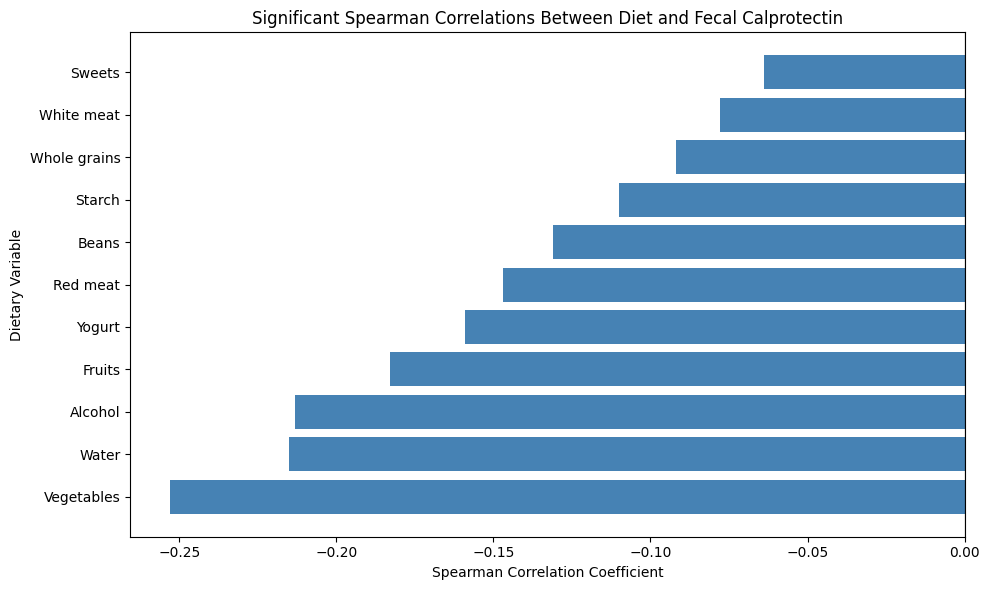

In [40]:
import matplotlib.pyplot as plt

# 这些名称的顺序对应完整 dietary_cols 的顺序
short_names = [
    "Red meat", "Fish", "Vegetables", "Fruits",
    "Whole grains", "Sweets", "Alcohol", "Processed meat",
    "Dairy", "Beans", "Eggs", "Water",
    "Starch", "Yogurt", "White meat", "Soft drinks"
]

food_name_map = dict(zip(dietary_cols, short_names))

# 只保留显著结果
sig_results = results_df[
    results_df["Significant"] == "Yes"
].copy()

# 根据原始食物名称自动匹配简称
sig_results["Food_short"] = sig_results["Food"].map(food_name_map)

# 按相关系数排列
sig_results = sig_results.sort_values("Correlation")

plt.figure(figsize=(10, 6))

colors = [
    "tomato" if value > 0 else "steelblue"
    for value in sig_results["Correlation"]
]

plt.barh(
    sig_results["Food_short"],
    sig_results["Correlation"],
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Significant Spearman Correlations Between Diet and Fecal Calprotectin")
plt.xlabel("Spearman Correlation Coefficient")
plt.ylabel("Dietary Variable")
plt.tight_layout()
plt.show()

# Group the samples into high inflammation level，gray zone and low inflammation level

In [41]:
import numpy as np

df_clean["inflammation_level"] = np.select(
    [
        df_clean["fecalcal"] < 50,
        (df_clean["fecalcal"] >= 50) &
        (df_clean["fecalcal"] <= 250),
        df_clean["fecalcal"] > 250
    ],
    [
        "Low",
        "Gray Zone",
        "High"
    ],
    default="Missing"
)


group_order = ["Low", "Gray Zone", "High"]

df_clean["inflammation_level"] = pd.Categorical(
    df_clean["inflammation_level"],
    categories=group_order,
    ordered=True
)

print(df_clean["inflammation_level"].value_counts().sort_index())

inflammation_level
Low          842
Gray Zone    643
High         254
Name: count, dtype: int64


## Compare Mean Dietary Frequency Scores Across Inflammation Groups

In [42]:
# Calculate mean dietary frequency scores for each group
diet_by_inflammation = (
    df_clean
    .dropna(subset=["inflammation_level"])
    .groupby(
        "inflammation_level",
        observed=True
    )[dietary_cols]
    .mean()
    .reindex(group_order)
    .round(2)
)

print(diet_by_inflammation)

                    Red meat (beef, hamburger, pork, lamb)  \
inflammation_level                                           
Low                                                   1.83   
Gray Zone                                             1.59   
High                                                  1.44   

                    Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)  \
inflammation_level                                                                      
Low                                                              0.73                   
Gray Zone                                                        0.80                   
High                                                             0.59                   

                    Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
inflammation_level                                                                                     
Low                                

#NHANES

# download the dataset

In [43]:
# ============================
# 1. Download NHANES 2009-2010 datasets
# ============================

import pandas as pd
import os

# Create folder
!mkdir -p NHANES_2009_2010

# Download files
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DEMO_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DR1TOT_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/MCQ_F.XPT

# Check downloaded files
!ls NHANES_2009_2010

DEMO_F.XPT  DR1TOT_F.XPT  MCQ_F.XPT


# read the files

In [44]:
# ============================
# 2. Read XPT files
# ============================

demo = pd.read_sas(
    "NHANES_2009_2010/DEMO_F.XPT"
)

diet = pd.read_sas(
    "NHANES_2009_2010/DR1TOT_F.XPT"
)

mcq = pd.read_sas(
    "NHANES_2009_2010/MCQ_F.XPT"
)


print("Demographics:", demo.shape)
print("Diet:", diet.shape)
print("MCQ:", mcq.shape)

Demographics: (10537, 43)
Diet: (10253, 166)
MCQ: (10109, 81)


In [45]:
print(demo.columns.tolist())

print(diet.columns.tolist())

print(mcq.columns.tolist())

['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'DMQMILIT', 'DMDBORN2', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ', 'DMDFMSIZ', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR', 'RIDEXPRG', 'DMDHRGND', 'DMDHRAGE', 'DMDHRBR2', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANG', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']
['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY', 'DR1LANG', 'DR1MNRSP', 'DR1HELPD', 'DBQ095Z', 'DBD100', 'DRQSPREP', 'DRQSDIET', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT5', 'DRQSDT6', 'DRQSDT7', 'DRQSDT8', 'DRQSDT9', 'DRQSDT10', 'DRQSDT11', 'DRQSDT12', 'DRQSDT91', 'DR1TNUMF', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TATOC', 'DR1TATOA', 'DR1TRET', 'DR1T

#Merge the files

In [46]:
# ============================
# 3. Merge datasets
# ============================

nhanes = demo.merge(
    diet,
    on="SEQN",
    how="inner"
)

nhanes = nhanes.merge(
    mcq,
    on="SEQN",
    how="left"
)

print(nhanes.shape)

nhanes.head()

(10253, 288)


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C
0,51624.0,6.0,2.0,1.0,1.0,34.0,409.0,410.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0
1,51625.0,6.0,2.0,2.0,1.0,4.0,49.0,50.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51626.0,6.0,2.0,1.0,1.0,16.0,202.0,202.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
3,51627.0,6.0,2.0,1.0,1.0,10.0,131.0,132.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
4,51628.0,6.0,2.0,2.0,2.0,60.0,722.0,722.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0


# Store the merged file

In [47]:
nhanes.to_csv(
    "NHANES_2009_2010_merged.csv",
    index=False
)

print("Saved!")

Saved!


In [48]:
df1 = pd.read_csv("NHANES_2009_2010_merged.csv")

In [49]:
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/CRP_F.XPT
crp = pd.read_sas(
    "NHANES_2009_2010/CRP_F.XPT"
)

df1 = df1.merge(
    crp,
    on="SEQN",
    how="left"
)

In [50]:
df1.shape


(10253, 289)

# Distributino of CRP

In [51]:
df1["LBXCRP"].describe()

,LBXCRP
count,8299.000000
mean,0.338788
std,0.713707
min,0.010000
25%,0.040000
50%,0.130000
75%,0.350000
max,18.010000


#Visualization of distribution of CRP

In [52]:
crp_data = df1["LBXCRP"].dropna()

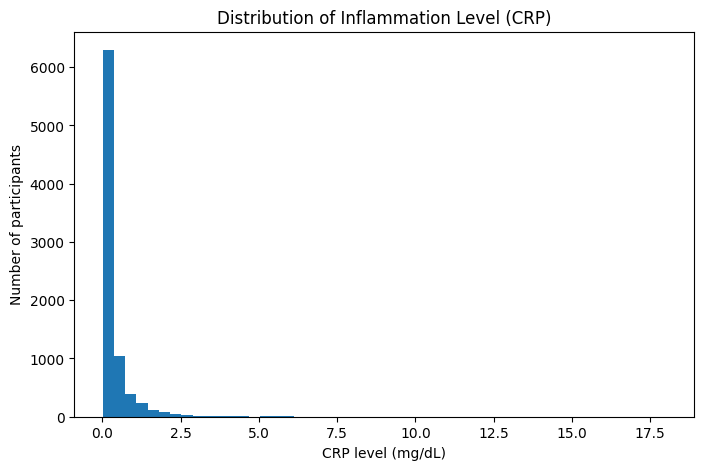

In [53]:


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    crp_data,
    bins=50
)

plt.xlabel("CRP level (mg/dL)")
plt.ylabel("Number of participants")
plt.title("Distribution of Inflammation Level (CRP)")

plt.show()

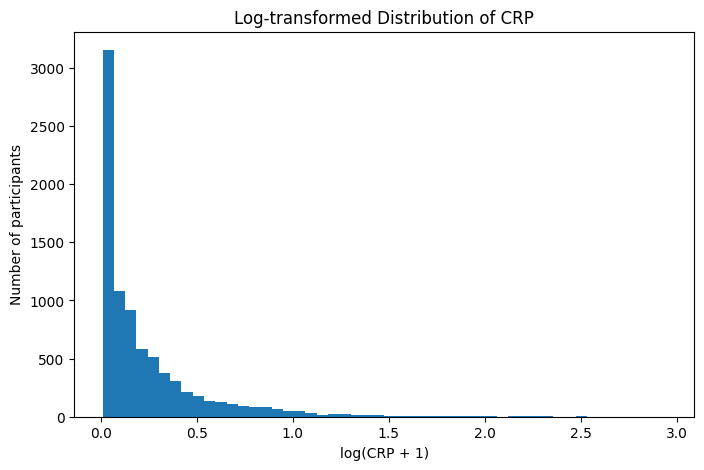

In [54]:
import numpy as np

plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(crp_data),
    bins=50
)

plt.xlabel("log(CRP + 1)")
plt.ylabel("Number of participants")
plt.title("Log-transformed Distribution of CRP")

plt.show()